### Write a code based on the Simple Linear Regression that predicts the score of the student based on the no of hours studied.


### Steps:--

1.  Import all the necessary libraries

In [566]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns


from sklearn.model_selection  import train_test_split
from sklearn.linear_model     import LinearRegression
from sklearn.metrics          import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score

2. Load the dataset

In [567]:
df = pd.read_csv('student_scores.csv')

In [568]:
df

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


### OBSERVATIONS:

1. The above dataset has two columns .

    (a.)  Hours -----> Hours studied by the student

    (b.)  Score -----> Score secured by the student

2. Based on the hours a student has studied, he has obtained the score.

3. Perform Data Exploration

In [569]:
### get the total length of the dataset

print("Total length of the dataset is:", len(df))

Total length of the dataset is: 25


In [570]:
### display the top five rows of the dataset

df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [571]:
### display the last five rows of the dataset

df.tail()

,Hours,Scores
20,2.7,30
21,4.8,54
22,3.8,35
23,6.9,76
24,7.8,86


In [572]:
### display all the columns used in the dataset

df.columns

Index(['Hours', 'Scores'], dtype='object')

In [573]:
### get the description about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [574]:
### get the desriptive statistical summary about the dataset

df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


4. Perform Data Cleaning

In [575]:
### Check for any NULL Values in the dataset

df.isnull().sum()

Hours     0
Scores    0
dtype: int64

### OBSERVATIONS:

1. There are no NULL Values in the dataset.

In [576]:
### Check for any duplicate records in te dataset

df[df.duplicated()]

,Hours,Scores


### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

5. Perform Visualization

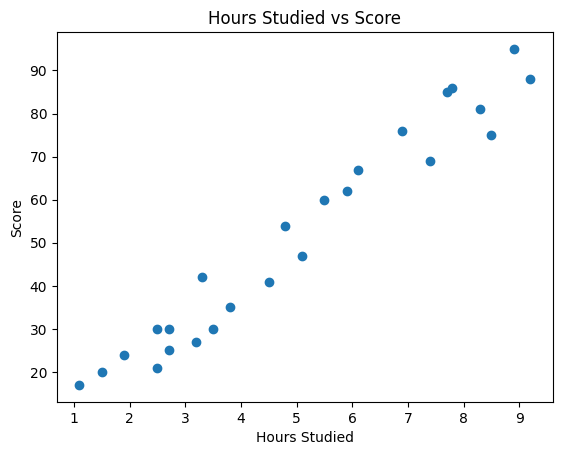

In [577]:
plt.scatter(df['Hours'], df['Scores'])
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Hours Studied vs Score')
plt.show()

### OBSERVATIONS:

1.  With the increase in the student studying for hours, the score of the student has increased.

2.  It depicts the linear relationship between the Hours studied vs the score obtained by the student.

6. Divide the dataset into independent and dependent variables

In [578]:
X = df[['Hours']]

Y = df['Scores']

In [579]:
X

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [580]:
Y

0     21
1     47
2     27
3     75
4     30
5     20
6     88
7     60
8     81
9     25
10    85
11    62
12    41
13    42
14    17
15    95
16    30
17    24
18    67
19    69
20    30
21    54
22    35
23    76
24    86
Name: Scores, dtype: int64

7. Divide the input and the output into independent and dependent variables

In [581]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [582]:
X_train

,Hours
9,2.7
13,3.3
1,5.1
22,3.8
5,1.5
2,3.2
12,4.5
15,8.9
3,8.5
4,3.5


In [583]:
X_test

,Hours
8,8.3
16,2.5
0,2.5
23,6.9
11,5.9


In [584]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (20, 1)
Shape of the input testing  data is: (5, 1)


In [585]:
Y_train

9     25
13    42
1     47
22    35
5     20
2     27
12    41
15    95
3     75
4     30
20    30
17    24
21    54
18    67
24    86
7     60
10    85
14    17
19    69
6     88
Name: Scores, dtype: int64

In [ ]:
Y_test

8     81
16    30
0     21
23    76
11    62
Name: Scores, dtype: int64

In [ ]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (20,)
Shape of the output testing  data is: (5,)


8. Train the linear model

In [ ]:
from sklearn.linear_model import LinearRegression

### create an object for linear regression

model = LinearRegression()

### using the object for linear regression, train the model

model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### OBSERVATIONS:

1.  The model has been trained with the help of the training data.

9.  Define the Model Parameters

In [ ]:
print("Slope     of the model is:", model.coef_[0])
print("Intercept of the model is:", model.intercept_)

Slope     of the model is: 9.682078154455697
Intercept of the model is: 2.826892353899737


10. Get the Prediction of the Model

In [ ]:
X_test

,Hours
8,8.3
16,2.5
0,2.5
23,6.9
11,5.9


In [ ]:
Y_pred = model.predict(X_test)

In [ ]:
Y_pred

array([83.18814104, 27.03208774, 27.03208774, 69.63323162, 59.95115347])

In [ ]:
### Compare the Actual vs Predicted Score

dfnew = pd.DataFrame({
    'Actual'      :      Y_test           ,
    'Predicted'   :      Y_pred           ,
    'Residual'    :      (Y_test - Y_pred)     
})

In [ ]:
dfnew

,Actual,Predicted,Residual
8,81,83.188141,-2.188141
16,30,27.032088,2.967912
0,21,27.032088,-6.032088
23,76,69.633232,6.366768
11,62,59.951153,2.048847


11. Get the Evaluation of the model

In [ ]:
mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error of the model is:", mae)

Mean Absolute Error of the model is: 3.9207511902099244


In [ ]:
mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error of the model is:", mse)

Mean Squared Error of the model is: 18.943211722315272


In [ ]:
rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared Error of the model is:", rmse)

Root Mean Squared Error of the model is: 4.352380006653288


In [ ]:
r2score = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2score)

R2 Score of the model is: 0.9678055545167994


12. Perform the best line of fit

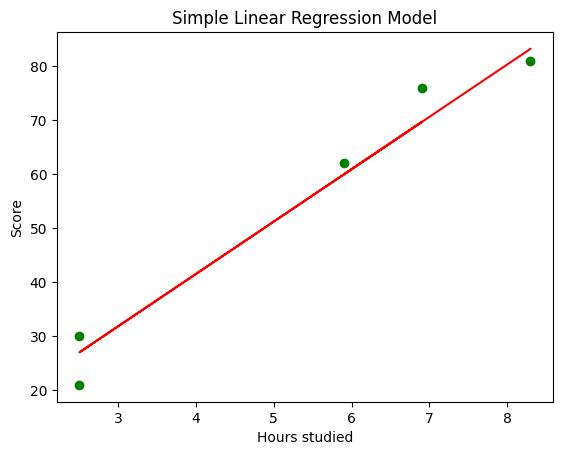

In [ ]:
plt.scatter(X_test, Y_test, color = 'green', label= 'Actual Data')

### plot the best line of fit
plt.plot(X_test, model.predict(X_test), color = 'red', label = 'Best line of fit')

### title of the graph
plt.title('Simple Linear Regression Model')

## X Axis
plt.xlabel('Hours studied')

## Y Axis
plt.ylabel('Score')

plt.show()

### OBSERVATIONS:

1. The above graph shows the linear relationship between the Hours studied vs Score.

2. With the increase in the hours studied, the score of the student increases.